<a href="https://colab.research.google.com/github/Mmbsaksd/fine_tuning/blob/master/Distill_BERT_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Classification using DistillBERT

In [1]:
# ============================================================
# Package Installation with UV (2026 standard)
# ============================================================
# Works in Google Colab (--system) and in a local uv venv.
# Locally you can also run: uv pip install <packages> in your terminal.
# import sys
# import subprocess

# IS_COLAB = "google.colab" in sys.modules

# def uv_install(*packages):
#     """Install packages with uv (adds --system automatically in Colab)."""
#     cmd = ["uv", "pip", "install"] + (["--system"] if IS_COLAB else []) + list(packages)
#     print(" ".join(cmd))
#     subprocess.run(cmd, check=True)

# uv_install(
#     "transformers",   # 5.x — latest
#     "datasets",       # 5.x — latest
#     "evaluate",
#     "accelerate",
#     "seqeval",
#     "matplotlib",
#     "seaborn",
#     "scikit-learn",
#     "pandas",
#     "numpy",
#     # "torch",        # uncomment locally if torch is missing (Colab ships it)
# )
# print("✅ All packages installed successfully!")

In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [3]:
# ============================================================
# Library Import Verification - FIXED
# ============================================================

import sys

def check_import(library_name, version_attr="__version__"):  # ✅ Removed unused import_statement
    try:
        module = __import__(library_name)
        version = getattr(module, version_attr, "version unknown")
        print(f"✅ {library_name:<20} version: {version}")
        return True
    except ImportError as e:
        print(f"❌ {library_name:<20} FAILED - {e}")
        return False

print("=" * 55)
print("       Library Import Verification Check")
print("=" * 55)
print(f"Python version: {sys.version}\n")

results = {}

# --- Core Libraries ---
print("📦 Core Libraries:")
results["transformers"]   = check_import("transformers")
results["datasets"]       = check_import("datasets")
results["evaluate"]       = check_import("evaluate")
results["accelerate"]     = check_import("accelerate")

# --- Evaluation ---
# print("\n📊 Evaluation:")
# try:
#     import seqeval
#     print(f"✅ {'seqeval':<20} imported successfully")
#     results["seqeval"] = True
# except ImportError as e:
#     print(f"❌ {'seqeval':<20} FAILED - {e}")
#     results["seqeval"] = False

# --- Visualization ---
print("\n🎨 Visualization:")
results["matplotlib"]     = check_import("matplotlib")
results["seaborn"]        = check_import("seaborn")

# --- Data & ML ---
print("\n🔢 Data & ML:")
results["sklearn"]        = check_import("sklearn")
results["pandas"]         = check_import("pandas")
results["numpy"]          = check_import("numpy")

# --- Deep Learning ---
print("\n🤖 Deep Learning:")
try:
    import torch
    print(f"✅ {'torch':<20} version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    results["torch"] = True
except ImportError as e:
    print(f"❌ {'torch':<20} FAILED - {e}")
    results["torch"] = False

# --- Summary ---
print("\n" + "=" * 55)
passed = sum(results.values())
total  = len(results)

if passed == total:
    print(f"✅ All {total}/{total} libraries imported successfully!")
else:
    print(f"⚠️  {passed}/{total} libraries passed")
    failed = [lib for lib, ok in results.items() if not ok]
    print(f"❌ Failed libraries: {', '.join(failed)}")
    print("\n💡 Fix failed installs with:")
    for lib in failed:
        print(f"   !uv pip install {lib}")

print("=" * 55)


       Library Import Verification Check
Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

📦 Core Libraries:
✅ transformers         version: 5.16.1
✅ datasets             version: 4.8.5
✅ evaluate             version: 0.4.6
✅ accelerate           version: 1.14.0

🎨 Visualization:
✅ matplotlib           version: 3.10.0
✅ seaborn              version: 0.13.2

🔢 Data & ML:
✅ sklearn              version: 1.6.1
✅ pandas               version: 2.2.3
✅ numpy                version: 2.1.3

🤖 Deep Learning:
✅ torch                version: 2.11.0+cu128
   CUDA available: True
   GPU: Tesla T4

✅ All 10/10 libraries imported successfully!


### Import Libraries

In [4]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Machine learning
from sklearn.metrics import classification_report, confusion_matrix

# Hugging Face libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
from datasets import load_dataset
import evaluate

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Configuration

In [5]:
# Model configuration
MODEL_NAME = "distilbert-base-uncased"  # Fast and efficient model
# MODEL_NAME = "answerdotai/ModernBERT-base"  # State-of-the-art (requires more memory)

# Dataset configuration
DATASET_NAME = "cardiffnlp/tweet_sentiment_multilingual"
DATASET_SUBSET = "english"  # Options: english, spanish, french, german, etc.

# Training hyperparameters (2026 standards)
LEARNING_RATE = 2e-5      # Standard for BERT models
BATCH_SIZE = 32         # Batch size for training
NUM_EPOCHS = 3            # Number of training epochs
WEIGHT_DECAY = 0.01       # Regularization
MAX_LENGTH = 128          # Maximum sequence length

# Label configuration
LABEL_NAMES = ["negative", "neutral", "positive"]
NUM_LABELS = len(LABEL_NAMES)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME} ({DATASET_SUBSET})")
print(f"Number of classes: {NUM_LABELS}")
print(f"Labels: {LABEL_NAMES}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print("=" * 60)

CONFIGURATION
Model: distilbert-base-uncased
Dataset: cardiffnlp/tweet_sentiment_multilingual (english)
Number of classes: 3
Labels: ['negative', 'neutral', 'positive']
Learning rate: 2e-05
Batch size: 32
Epochs: 3


## Dataset Loading

In [6]:
# Optional: Hugging Face authentication (only needed for gated datasets/models)
# In Colab: add HF_TOKEN via Secrets (🔑). Locally: set it below or use `huggingface-cli login`.
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('HF_TOKEN_WRITE')
    print("✅ Loaded HF_TOKEN from Colab secrets")
except Exception:
    HF_TOKEN = None  # public datasets work without a token


✅ Loaded HF_TOKEN from Colab secrets


In [7]:
print("Loading dataset...")
# datasets 5.x no longer supports dataset loading scripts, so we load the
# Hub's official parquet export (refs/convert/parquet) — identical data.
dataset = load_dataset(
    DATASET_NAME,
    revision="refs/convert/parquet",
    data_dir=DATASET_SUBSET,  # language folder, e.g. "english"
)

print("\n✅ Dataset loaded successfully!\n")
print("Dataset structure:")
print(dataset)

Loading dataset...


0000.parquet:   0%|          | 0.00/155k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/29.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/64.8k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


✅ Dataset loaded successfully!

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 324
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 870
    })
})


In [8]:
# Convert to pandas DataFrame for easier exploration
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

print("Dataset Sizes:")
print(f"  Training set:   {len(train_df)} samples")
print(f"  Validation set: {len(val_df)} samples")
print(f"  Test set:       {len(test_df)} samples")

print("\nClass Distribution (Training Set):")
class_dist = train_df['label'].value_counts().sort_index()
for i, count in enumerate(class_dist):
    print(f"  {LABEL_NAMES[i]:10s}: {count:4d} samples ({100*count/len(train_df):.1f}%)")

Dataset Sizes:
  Training set:   1839 samples
  Validation set: 324 samples
  Test set:       870 samples

Class Distribution (Training Set):
  negative  :  613 samples (33.3%)
  neutral   :  613 samples (33.3%)
  positive  :  613 samples (33.3%)


### Visualize Class Distribution

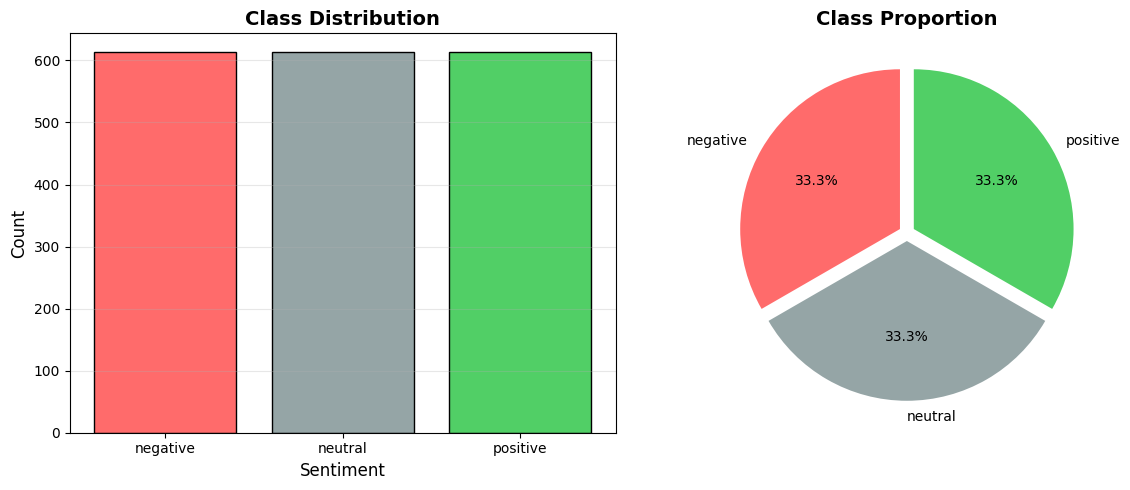


📊 Visualization saved as 'class_distribution.png'


In [9]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
axes[0].bar(LABEL_NAMES, train_df['label'].value_counts().sort_index(),
            color=['#ff6b6b', '#95a5a6', '#51cf66'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
sizes = train_df['label'].value_counts().sort_index().values
axes[1].pie(sizes, labels=LABEL_NAMES, autopct='%1.1f%%',
            colors=['#ff6b6b', '#95a5a6', '#51cf66'],
            explode=(0.05, 0.05, 0.05), startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved as 'class_distribution.png'")

## Dataset Samples

In [10]:
print("Sample Examples from Training Set:")
print("=" * 80)

# Show examples from each class
for class_id in range(NUM_LABELS):
    sample_idx = train_df[train_df['label'] == class_id].index[0]
    example = dataset['train'][int(sample_idx)]  # Convert numpy.int64 to int

    print(f"\nClass: {LABEL_NAMES[class_id].upper()}")
    print(f"Text: \"{example['text'][:100]}...\"")
    print("-" * 80)

Sample Examples from Training Set:

Class: NEGATIVE
Text: "okay i\u2019m sorry but TAYLOR SWIFT LOOKS NOTHING LIKE JACKIE O SO STOP COMPARING THE TWO. c\u2019m..."
--------------------------------------------------------------------------------

Class: NEUTRAL
Text: "@user the DC comics site has Batman 44 releases on the 9th but its out now? ..."
--------------------------------------------------------------------------------

Class: POSITIVE
Text: ""Frank Gaffrey\u002c Cliff May\u002c Steve Emerson: Brilliant. \""""Looming Threats: Iran\u002c Hezb..."
--------------------------------------------------------------------------------


### Tokenizer

In [11]:
# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.model_max_length = MAX_LENGTH

print(f"\n✅ Tokenizer loaded!")
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")
print(f"   Max sequence length: {tokenizer.model_max_length}")

Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


✅ Tokenizer loaded!
   Vocabulary size: 30,522
   Max sequence length: 128


### Tokenization

In [12]:
def tokenize_function(examples):
    """
    Tokenize text examples for BERT.

    Args:
        examples: Dictionary with 'text' key

    Returns:
        Tokenized inputs (input_ids, attention_mask, etc.)
    """
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

print("✅ Tokenization function defined!")

✅ Tokenization function defined!


In [13]:
print("Tokenizing dataset (this may take a minute)...\n")

# Tokenize all splits
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing"
)

# Remove the original text column (not needed after tokenization)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Rename 'label' to 'labels' (Trainer expects this name)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Set format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("\n✅ Tokenization complete!")
print(f"\nTokenized dataset features: {list(tokenized_datasets['train'].features.keys())}")

Tokenizing dataset (this may take a minute)...



Tokenizing:   0%|          | 0/1839 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/324 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/870 [00:00<?, ? examples/s]


✅ Tokenization complete!

Tokenized dataset features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [14]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 324
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 870
    })
})

In [15]:
tokenized_datasets['train'][0]

{'labels': tensor(0),
 'input_ids': tensor([  101,  3100,  1045,  1032, 23343, 24096,  2683,  2213,  3374,  2021,
          4202,  9170,  3504,  2498,  2066,  9901,  1051,  2061,  2644, 13599,
          1996,  2048,  1012,  1039,  1032, 23343, 24096,  2683,  8202,  2637,
          4995,  1032, 23343, 24096,  2683,  2102,  2017,  5305,  1997,  2014,
          2664,  1029,  1006,  3374,  1007,   102,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

In [16]:
# Check a tokenized example
sample = tokenized_datasets['train'][0]

print("Sample Tokenized Example:")
print("=" * 60)
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention Mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['labels']} ({LABEL_NAMES[sample['labels']]})")
print(f"\nFirst 20 input IDs: {sample['input_ids'][:20].tolist()}")
print(f"First 20 attention mask: {sample['attention_mask'][:20].tolist()}")

Sample Tokenized Example:
Input IDs shape: torch.Size([128])
Attention Mask shape: torch.Size([128])
Label: 0 (negative)

First 20 input IDs: [101, 3100, 1045, 1032, 23343, 24096, 2683, 2213, 3374, 2021, 4202, 9170, 3504, 2498, 2066, 9901, 1051, 2061, 2644, 13599]
First 20 attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [17]:
# ============================================================
# Device Selection — local Apple Silicon (MPS) or Colab GPU (CUDA)
# ============================================================
import torch

FORCE_DEVICE = "cuda"   # <-- set "cuda" for Colab GPU, "mps" for Apple Silicon, None = auto

def pick_device():
    if FORCE_DEVICE:
        return torch.device(FORCE_DEVICE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = pick_device()

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available:  {torch.backends.mps.is_available()}")

if device.type == "cuda":
    print(f"\n✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"   BF16 supported: {torch.cuda.is_bf16_supported()}")
elif device.type == "mps":
    print("\n✅ Apple Silicon GPU detected — using MPS acceleration")
else:
    print("\n⚠️ No GPU detected. Training will run on CPU (slower).")
    print("   Colab: Runtime > Change runtime type > T4 GPU")

print(f"\n📍 Using device: {device}")
print("=" * 60)


DEVICE CONFIGURATION
PyTorch version: 2.11.0+cu128
CUDA available: True
MPS available:  False

✅ GPU detected: Tesla T4
   GPU memory: 15.64 GB
   BF16 supported: True

📍 Using device: cuda


In [18]:
# Create label mappings
label2id = {label: i for i, label in enumerate(LABEL_NAMES)}
id2label = {i: label for i, label in enumerate(LABEL_NAMES)}

print(f"Loading model: {MODEL_NAME}")
print("(This downloads the pre-trained model weights...)\n")

# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# Move model to GPU if available
model.to(device)

print(f"\n✅ Model loaded successfully!")

Loading model: distilbert-base-uncased
(This downloads the pre-trained model weights...)



model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded successfully!


In [19]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Information:")
print("=" * 60)
print(f"Model type: {MODEL_NAME}")
print(f"Number of classes: {NUM_LABELS}")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1e6:.1f} MB (float32)")

Model Information:
Model type: distilbert-base-uncased
Number of classes: 3

Total parameters: 66,955,779
Trainable parameters: 66,955,779
Model size: ~267.8 MB (float32)


### Training Setup

In [20]:
# Load evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Compute evaluation metrics.

    Args:
        eval_pred: Contains predictions and labels

    Returns:
        Dictionary of metrics
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_weighted = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_weighted": f1_weighted["f1"],
        "f1_macro": f1_macro["f1"]
    }

print("✅ Metrics function defined!")

✅ Metrics function defined!


In [21]:
# Determine mixed precision
# Mixed precision: bf16/fp16 only on CUDA (MPS/CPU run full precision)
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()
use_fp16 = device.type == "cuda" and not use_bf16
# Fused optimizer is CUDA-only; fall back to standard AdamW elsewhere
OPTIMIZER = "adamw_torch_fused" if device.type == "cuda" else "adamw_torch"

# Define training arguments
training_args = TrainingArguments(
    output_dir="./sentiment-model",

    # Hyperparameters
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,

    # Evaluation (2026 standard: eval_strategy, not evaluation_strategy)
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",

    # Mixed precision
    fp16=use_fp16,
    bf16=use_bf16,

    # Optimizer (2026 standard: faster than standard AdamW)
    optim=OPTIMIZER,

    # Logging
    logging_steps=50,
    report_to="none",

    # Reproducibility
    seed=SEED,
)

print("Training Configuration:")
print("=" * 60)
print(f"Learning rate: {training_args.learning_rate}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Optimizer: {training_args.optim}")
print(f"Mixed precision: {'bf16' if training_args.bf16 else 'fp16' if training_args.fp16 else 'none'}")
print(f"Evaluation: {training_args.eval_strategy}")

Training Configuration:
Learning rate: 2e-05
Batch size: 32
Epochs: 3
Optimizer: OptimizerNames.ADAMW_TORCH_FUSED
Mixed precision: bf16
Evaluation: IntervalStrategy.EPOCH


### Trainer Setup

In [22]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# Calculate training statistics
steps_per_epoch = len(tokenized_datasets["train"]) // BATCH_SIZE
total_steps = steps_per_epoch * NUM_EPOCHS

print("✅ Trainer initialized!\n")
print("Training Statistics:")
print("=" * 60)
print(f"Training samples: {len(tokenized_datasets['train'])}")
print(f"Validation samples: {len(tokenized_datasets['validation'])}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_steps}")

✅ Trainer initialized!

Training Statistics:
Training samples: 1839
Validation samples: 324
Steps per epoch: 57
Total training steps: 171


In [23]:
print("\n" + "=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print("\n⏳ Training in progress... (this will take a few minutes)\n")

# Start training
train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING COMPLETED! 🎉")
print("=" * 60)


STARTING TRAINING

⏳ Training in progress... (this will take a few minutes)



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,1.049751,0.873740,0.608025,0.552935,0.552935
2,0.830440,0.722566,0.697531,0.688146,0.688146
3,0.678500,0.711745,0.682099,0.673573,0.673573


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETED! 🎉


In [24]:
# Display training results
print("\nTraining Results:")
print("-" * 60)
for key, value in train_result.metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")


Training Results:
------------------------------------------------------------
train_runtime: 118.3944
train_samples_per_second: 46.5980
train_steps_per_second: 1.4700
total_flos: 182708917892352.0000
train_loss: 0.8273
epoch: 3.0000


### Evaluation

In [25]:
print("Evaluating on test set...\n")

# Evaluate
test_results = trainer.evaluate(tokenized_datasets["test"])

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")

Evaluating on test set...



Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted,F1 Macro
0.678500,0.747010,3,0.659770,0.649310,0.649310


TEST SET RESULTS
eval_loss: 0.7470
eval_accuracy: 0.6598
eval_f1_weighted: 0.6493
eval_f1_macro: 0.6493


In [26]:
# Get predictions
print("Generating predictions for detailed analysis...\n")
predictions_output = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

# Classification report
print("Classification Report:")
print("=" * 60)
print(classification_report(labels, predictions, target_names=LABEL_NAMES))

Generating predictions for detailed analysis...



Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.89      0.73       290
     neutral       0.57      0.43      0.49       290
    positive       0.80      0.66      0.73       290

    accuracy                           0.66       870
   macro avg       0.67      0.66      0.65       870
weighted avg       0.67      0.66      0.65       870



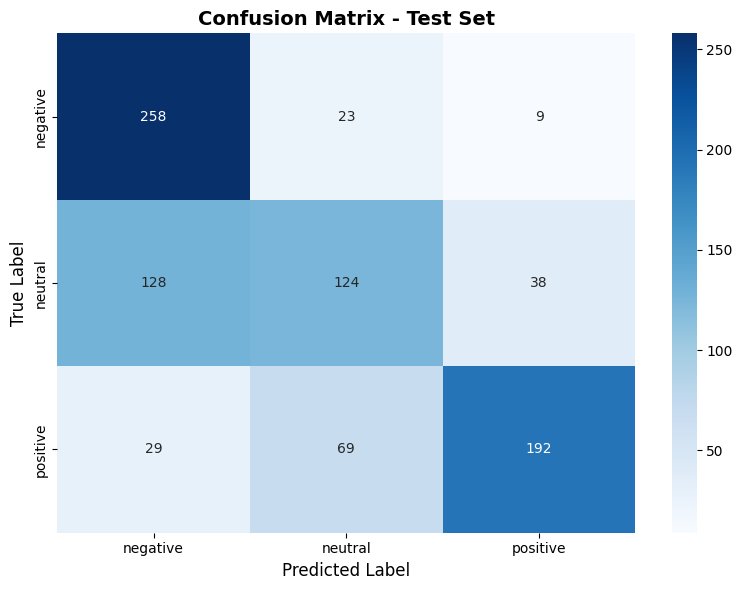


Per-Class Accuracy:
negative  : 88.97%
neutral   : 42.76%
positive  : 66.21%


In [27]:
# Create confusion matrix
cm = confusion_matrix(labels, predictions)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\nPer-Class Accuracy:")
print("=" * 60)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (name, acc) in enumerate(zip(LABEL_NAMES, class_accuracies)):
    print(f"{name:10s}: {acc:.2%}")

## Predection or Inference